In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/luisjaneirobezi/hotelbooikings/hotel_bookings.csv


In [3]:
# =====================================================
# HOTEL BOOKINGS DATA PREPARATION
# Revenue Management Cancellation Analysis
# =====================================================

import pandas as pd

# -----------------------------------------------------
# PASO 1 — Cargar dataset
# -----------------------------------------------------

# Cargar dataset
df = pd.read_csv("/kaggle/input/datasets/luisjaneirobezi/hotelbooikings/hotel_bookings.csv")

# Ver estructura inicial
print("Shape inicial:", df.shape)
print("\nColumnas del dataset:")
print(df.columns)

# -----------------------------------------------------
# PASO 2 — Crear métricas base necesarias
# -----------------------------------------------------

# Total de noches de la reserva
df["total_nights"] = df["stays_in_weekend_nights"] + df["stays_in_week_nights"]

# Cada fila representa una reserva
df["reservations"] = 1

# -----------------------------------------------------
# PASO 3 — Validar datos problemáticos
# -----------------------------------------------------

# Reservas con 0 noches
zero_nights = df[df["total_nights"] == 0]
print("\nReservas con 0 noches:", len(zero_nights))

# Inconsistencias entre estado y cancelación
inconsistencies = df[
    (df["reservation_status"] == "Canceled") &
    (df["is_canceled"] == 0)
]

print("Inconsistencias cancelación:", len(inconsistencies))

# Valores nulos importantes
print("\nValores nulos:")
print(df[
    [
        "market_segment",
        "distribution_channel",
        "lead_time",
        "arrival_date_month",
        "arrival_date_year",
        "is_canceled"
    ]
].isnull().sum())

# -----------------------------------------------------
# PASO 4 — Limpieza básica de fechas
# -----------------------------------------------------

# Convertir nombre de mes a número
df["arrival_month_number"] = pd.to_datetime(
    df["arrival_date_month"], format="%B"
).dt.month

# Crear fecha completa de llegada
df["arrival_date"] = pd.to_datetime(
    dict(
        year=df["arrival_date_year"],
        month=df["arrival_month_number"],
        day=df["arrival_date_day_of_month"]
    )
)

# -----------------------------------------------------
# PASO 5 — Crear columna de mes cronológico
# -----------------------------------------------------

df["arrival_month"] = df["arrival_date"].dt.to_period("M")

# -----------------------------------------------------
# PASO 6 — Crear buckets de lead time
# -----------------------------------------------------

bins = [-1, 7, 30, 90, 180, 10000]
labels = ["0-7", "8-30", "31-90", "91-180", "180+"]

df["lead_time_bucket"] = pd.cut(
    df["lead_time"],
    bins=bins,
    labels=labels
)

# -----------------------------------------------------
# PASO 7 — Eliminar columnas irrelevantes
# -----------------------------------------------------

columns_to_drop = [
    "agent",
    "company",
    "required_car_parking_spaces",
    "total_of_special_requests",
    "booking_changes",
    "days_in_waiting_list",
    "adults",
    "children",
    "babies"
]

df_clean = df.drop(columns=columns_to_drop)

# -----------------------------------------------------
# PASO 8 — Estructura final del dataset
# -----------------------------------------------------

print("\nShape final:", df_clean.shape)

print("\nColumnas finales:")
print(df_clean.columns)

print("\nPrimeras filas:")
print(df_clean.head())

Shape inicial: (119390, 32)

Columnas del dataset:
Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

Reservas con 0 noches: 715
Inconsistencias cancelación: 0

Valores nulos:
market_segment          0
distribution_channel    0
lead_time               0
arrival_date_month      0
arrival_date_year       0
is_canceled             0


In [4]:
import pandas as pd

# Crear variable total_nights si aún no existe
df["total_nights"] = df["stays_in_weekend_nights"] + df["stays_in_week_nights"]

# Crear indicador de reservas con 0 noches
df["zero_nights"] = df["total_nights"] == 0

# ---------------------------------------------------
# 1. Tabla cruzada principal
# ---------------------------------------------------

crosstab = pd.crosstab(df["zero_nights"], df["is_canceled"])
print("Tabla cruzada zero_nights vs is_canceled:\n")
print(crosstab)

# ---------------------------------------------------
# 2. Tabla en porcentajes
# ---------------------------------------------------

crosstab_pct = pd.crosstab(
    df["zero_nights"],
    df["is_canceled"],
    normalize="index"
)

print("\nProporciones:\n")
print(crosstab_pct)

# ---------------------------------------------------
# 3. Ver cuántas reservas con 0 noches están canceladas
# ---------------------------------------------------

zero_nights_total = df[df["zero_nights"]].shape[0]
zero_nights_canceled = df[(df["zero_nights"]) & (df["is_canceled"] == 1)].shape[0]

print("\nReservas con 0 noches:", zero_nights_total)
print("Reservas con 0 noches canceladas:", zero_nights_canceled)

ratio = zero_nights_canceled / zero_nights_total
print("Porcentaje de cancelación en reservas con 0 noches:", round(ratio*100,2), "%")

Tabla cruzada zero_nights vs is_canceled:

is_canceled      0      1
zero_nights              
False        74486  44189
True           680     35

Proporciones:

is_canceled         0         1
zero_nights                    
False        0.627647  0.372353
True         0.951049  0.048951

Reservas con 0 noches: 715
Reservas con 0 noches canceladas: 35
Porcentaje de cancelación en reservas con 0 noches: 4.9 %


In [5]:
# Crear total_nights si aún no existe
df["total_nights"] = df["stays_in_weekend_nights"] + df["stays_in_week_nights"]

# Filtrar reservas con 0 noches
zero_nights_df = df[df["total_nights"] == 0]

# Ver distribución del estado de reserva
print(zero_nights_df["reservation_status"].value_counts())

# Cruzar estado con cancelación
print(pd.crosstab(zero_nights_df["reservation_status"], zero_nights_df["is_canceled"]))

reservation_status
Check-Out    680
Canceled      22
No-Show       13
Name: count, dtype: int64
is_canceled           0   1
reservation_status         
Canceled              0  22
Check-Out           680   0
No-Show               0  13


Lo realmente raro: 680 Check-Out con 0 noches

Aquí está el verdadero misterio.

reservation_status = Check-Out
total_nights = 0

Eso significa literalmente:

el cliente completó la estancia pero no pasó ninguna noche

Físicamente eso no tiene sentido.

Así que aquí hay solo tres explicaciones posibles.

Explicación más probable

Son errores de registro del PMS.

Probablemente:

la reserva existió

el sistema la cerró como Check-Out

pero las noches nunca se registraron

Esto pasa mucho cuando datasets se exportan de varios sistemas.

Otra posibilidad

Reservas de uso interno del hotel:

habitaciones bloqueadas

reservas administrativas

reservas para staff

pruebas del sistema

La pista importante

Mira el tamaño del fenómeno:

680 / 119390 ≈ 0.57 %

Es menos del 1% del dataset.

En análisis de negocio esto se considera ruido estadístico.

In [7]:
df = df[df["total_nights"] > 0]

In [8]:
df.to_csv("/kaggle/working/hotel_bookings_clean.csv", index=False)

print("Archivo guardado correctamente")

Archivo guardado correctamente


In [9]:
pivot = df.pivot_table(
    index="market_segment",
    values=["reservations", "is_canceled"],
    aggfunc="sum"
)

pivot["cancellation_rate"] = (
    pivot["is_canceled"] / pivot["reservations"]
)

pivot = pivot.sort_values("cancellation_rate", ascending=False)

print(pivot)

                is_canceled  reservations  cancellation_rate
market_segment                                              
Undefined                 2             2           1.000000
Groups                12096         19775           0.611681
Online TA             20724         56165           0.368984
Offline TA/TO          8308         24070           0.345160
Aviation                 51           231           0.220779
Corporate               990          5242           0.188859
Direct                 1930         12470           0.154771
Complementary            88           720           0.122222


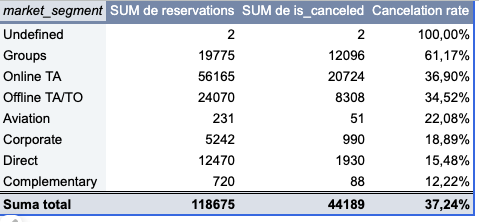

In [10]:
# Pivot por canal de distribución
channel_pivot = df.pivot_table(
    index="distribution_channel",
    values=["reservations", "is_canceled"],
    aggfunc="sum"
)

# Calcular cancellation rate en porcentaje
channel_pivot["cancellation_rate_%"] = (
    channel_pivot["is_canceled"] / channel_pivot["reservations"]
) * 100

# Redondear para que se vea mejor
channel_pivot["cancellation_rate_%"] = channel_pivot["cancellation_rate_%"].round(2)

# Ordenar de mayor a menor cancelación
channel_pivot = channel_pivot.sort_values("cancellation_rate_%", ascending=False)

print(channel_pivot)

                      is_canceled  reservations  cancellation_rate_%
distribution_channel                                                
Undefined                       4             5                80.00
TA/TO                       40134         97404                41.20
Corporate                    1462          6597                22.16
GDS                            37           190                19.47
Direct                       2552         14479                17.63


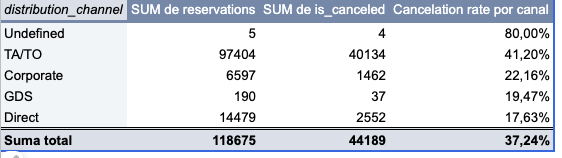

In [11]:
# Pivot por lead time bucket
leadtime_pivot = df.pivot_table(
    index="lead_time_bucket",
    values=["reservations", "is_canceled"],
    aggfunc="sum"
)

# Calcular cancellation rate en porcentaje
leadtime_pivot["cancellation_rate_%"] = (
    leadtime_pivot["is_canceled"] / leadtime_pivot["reservations"]
) * 100

# Redondear
leadtime_pivot["cancellation_rate_%"] = leadtime_pivot["cancellation_rate_%"].round(2)

# Ordenar por el bucket lógico (opcional pero recomendable)
leadtime_pivot = leadtime_pivot.sort_index()

print(leadtime_pivot)

                  is_canceled  reservations  cancellation_rate_%
lead_time_bucket                                                
0-7                      1879         19290                 9.74
8-30                     5277         18863                27.98
31-90                   11137         29459                37.81
91-180                  11819         26402                44.77
180+                    14077         24661                57.08


/tmp/ipykernel_55/2833828395.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  leadtime_pivot = df.pivot_table(


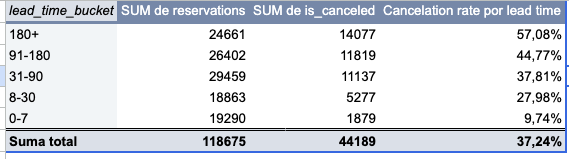

In [12]:
# Pivot por mes de llegada
month_pivot = df.pivot_table(
    index="arrival_month_number",
    values=["reservations", "is_canceled"],
    aggfunc="sum"
)

# Calcular cancellation rate en porcentaje
month_pivot["cancellation_rate_%"] = (
    month_pivot["is_canceled"] / month_pivot["reservations"]
) * 100

# Redondear para mejor lectura
month_pivot["cancellation_rate_%"] = month_pivot["cancellation_rate_%"].round(2)

# Ordenar por mes
month_pivot = month_pivot.sort_index()

print(month_pivot)

                      is_canceled  reservations  cancellation_rate_%
arrival_month_number                                                
1                            1804          5876                30.70
2                            2688          8007                33.57
3                            3147          9728                32.35
4                            4516         11051                40.87
5                            4675         11712                39.92
6                            4533         10897                41.60
7                            4741         12601                37.62
8                            5237         13826                37.88
9                            4115         10485                39.25
10                           4245         11074                38.33
11                           2121          6723                31.55
12                           2367          6695                35.35


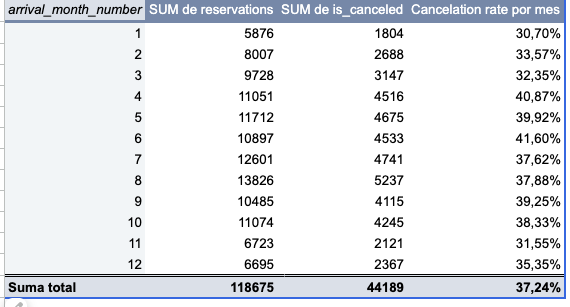